In [60]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt 
from dotenv import load_dotenv

load_dotenv()

db_url = os.getenv("DB_URL")

#Query for database
engine = create_engine(db_url)

query = "SELECT * FROM v_houston_grid_resilience"
#Execute query and load data into DataFrame
df = pd.read_sql_query(query,con= engine)

print(df.head())

#FEATURE ENGINEERING ///////////

#calculating the TMEAN using vectorized operations
df['TMEAN'] = df[['TMAX', 'TMIN']].mean(axis=1)

#Calculate Heating Degree Days (HDD)
df['HDD'] = (65-df['TMEAN']).clip(lower=0)

#Calculate Cooling Degree Days (CDD)
df['CDD'] = (df['TMEAN']-65).clip(lower=0)

#Need the thermallag the df by grouping by plant_id_eia
df['TMEAN_lag1'] = df.groupby('plant_id_eia')['TMEAN'].shift(1)

#Need the utilization percentage lag
df['utilization_pct_lag1'] = df.groupby('plant_id_eia')['utilization_pct'].shift(1)

df_cleaned = df.dropna(subset=['TMEAN_lag1', 'utilization_pct_lag1'])

print(df[['report_date','TMEAN','HDD','CDD','TMEAN_lag1','utilization_pct_lag1']])


      county         city  plant_id_eia                  plant_name_eia  \
0  Fort Bend    Thompsons          3470                      W A Parish   
1     Harris    Deer Park         55464         Deer Park Energy Center   
2     Harris  Channelview         55187  Channelview Cogeneration Plant   
3     Harris     Pasadena         55299       Channel Energy Center LLC   
4  Galveston   Texas City         55470                   Green Power 2   

  report_date  hours_in_month fuel_type_code_pudl  total_capacity_mw  \
0  2021-01-01             744                coal        4008.399944   
1  2021-01-01             744                 gas        1176.000000   
2  2021-01-01             744                 gas         918.300018   
3  2021-01-01             744                 gas         923.800003   
4  2021-01-01             744                 gas         861.000000   

   total_generation_mwh  utilization_pct  TMAX  TMIN  PRCP  
0         752287.437500            25.23    78    31  2

### Data Pipeline: Database Extraction & Initial Feature Engineering

I connected to my local MySQL database (`pudl_analysis`) using SQLAlchemy to pull the grid resilience view directly into Pandas for analysis.

#### 1. Vectorized Weather Features
Using vectorized Pandas operations, I engineered core weather metrics anchored to the standard 65°F comfort baseline:
* **`TMEAN`:** The average temperature calculated from `TMAX` and `TMIN`.
* **`HDD` (Heating Degree Days):** Captures heating demand when temps fall below 65°F using `.clip(lower=0)` to zero out warmer periods.
* **`CDD` (Cooling Degree Days):** Captures cooling demand when temps rise above 65°F using `.clip(lower=0)` to zero out cooler periods.

#### 2. Plant-Level Lag Features & Cleanup
To capture historical momentum and thermal persistence, I generated 1 period lagged features (`utilization_pct_lag1` and `TMEAN_lag1`). Grouping by `plant_id_eia` before calling `.shift(1)` is critical—it ensures each plant only looks at its own past history, preventing data leakage across different plants.

Finally, I dropped the `NaN` values created in the first recorded month of each plant so the feature set is clean for downstream models.

In [2]:
#EDA and Data Cleaning
df_cleaned['plant_id_eia'].nunique() 

df_cleaned.describe()

,plant_id_eia,report_date,hours_in_month,total_capacity_mw,total_generation_mwh,utilization_pct,TMAX,TMIN,PRCP,TMEAN,HDD,CDD,TMEAN_lag1,utilization_pct_lag1
count,5913.000000,5913,5913.000000,5913.000000,5.913000e+03,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000
mean,56298.476746,2023-03-13 08:33:07.214611,730.597666,219.641754,5.501014e+04,18.100504,92.151361,49.190766,4.039806,70.671064,2.748858,8.419922,70.791307,18.127232
min,3457.000000,2021-01-01 00:00:00,672.000000,1.200000,-3.240000e+03,-4.500000,78.000000,13.000000,0.010000,47.500000,0.000000,0.000000,47.500000,-4.500000
25%,55299.000000,2022-04-01 00:00:00,720.000000,1.200000,1.762000e+01,1.670000,86.000000,36.000000,1.830000,61.000000,0.000000,0.000000,61.000000,1.670000
50%,64528.000000,2023-04-01 00:00:00,744.000000,9.000000,3.408200e+01,3.250000,91.000000,47.000000,2.980000,69.500000,0.000000,4.500000,69.500000,3.270000
75%,64945.000000,2024-03-01 00:00:00,744.000000,209.300003,2.514600e+04,28.600000,99.000000,67.000000,4.970000,83.500000,4.000000,18.500000,83.500000,28.840000
max,68737.000000,2025-01-01 00:00:00,744.000000,4008.399944,1.501541e+06,124.810000,109.000000,75.000000,11.170000,89.500000,17.500000,24.500000,89.500000,124.810000
std,16844.798688,NaN,19.175582,559.095684,1.383940e+05,25.936359,7.968875,17.117523,3.108231,12.309507,4.692319,9.121839,12.288536,25.915571


In [3]:
bad_rows_count = (~df_cleaned['utilization_pct'].between(0, 100)).sum()
print(f"Out-of-bounds rows detected: {bad_rows_count}")


df_cleaned['utilization_pct'] = df_cleaned['utilization_pct'].clip(lower=0, upper=100)


remaining_bad = (~df_cleaned['utilization_pct'].between(0, 100)).sum()
print(f"Out-of-bounds rows remaining: {remaining_bad}")
print(f"New range: {df_cleaned['utilization_pct'].min()}% to {df_cleaned['utilization_pct'].max()}%")

Out-of-bounds rows detected: 252
Out-of-bounds rows remaining: 0
New range: -0.0% to 100.0%


### Data Quality Check: Range Validation (`utilization_pct`)

I checked for rows where `utilization_pct` falls outside the logical range of **0% to 100%**. 

Because a power plant's utilization cannot physically be negative or exceed its total capacity, any values outside this 0–100% threshold indicate potential data entry errors, missing flags, or sensor anomalies that must be addressed before modeling.

In [4]:
df_cleaned.describe()

,plant_id_eia,report_date,hours_in_month,total_capacity_mw,total_generation_mwh,utilization_pct,TMAX,TMIN,PRCP,TMEAN,HDD,CDD,TMEAN_lag1,utilization_pct_lag1
count,5913.000000,5913,5913.000000,5913.000000,5.913000e+03,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000,5913.000000
mean,56298.476746,2023-03-13 08:33:07.214611,730.597666,219.641754,5.501014e+04,18.086753,92.151361,49.190766,4.039806,70.671064,2.748858,8.419922,70.791307,18.127232
min,3457.000000,2021-01-01 00:00:00,672.000000,1.200000,-3.240000e+03,-0.000000,78.000000,13.000000,0.010000,47.500000,0.000000,0.000000,47.500000,-4.500000
25%,55299.000000,2022-04-01 00:00:00,720.000000,1.200000,1.762000e+01,1.670000,86.000000,36.000000,1.830000,61.000000,0.000000,0.000000,61.000000,1.670000
50%,64528.000000,2023-04-01 00:00:00,744.000000,9.000000,3.408200e+01,3.250000,91.000000,47.000000,2.980000,69.500000,0.000000,4.500000,69.500000,3.270000
75%,64945.000000,2024-03-01 00:00:00,744.000000,209.300003,2.514600e+04,28.600000,99.000000,67.000000,4.970000,83.500000,4.000000,18.500000,83.500000,28.840000
max,68737.000000,2025-01-01 00:00:00,744.000000,4008.399944,1.501541e+06,100.000000,109.000000,75.000000,11.170000,89.500000,17.500000,24.500000,89.500000,124.810000
std,16844.798688,NaN,19.175582,559.095684,1.383940e+05,25.769590,7.968875,17.117523,3.108231,12.309507,4.692319,9.121839,12.288536,25.915571


In [5]:
#Need to see how many plants sit at a 0% utilization percentage for a long time. This could indicate that the plant is not operational or has been decommissioned. By identifying these plants, we can better understand the overall resilience of the grid and potentially identify areas for improvement.
(df_cleaned['utilization_pct'] == 0).mean()*100

np.float64(12.531709791983763)

In [6]:
corr_matrix = df_cleaned[['utilization_pct', 'TMEAN', 'HDD','CDD', 'utilization_pct_lag1']].corr(method='pearson', numeric_only=True)
print(corr_matrix)

                      utilization_pct     TMEAN       HDD       CDD  \
utilization_pct              1.000000  0.075664 -0.030413  0.086460   
TMEAN                        0.075664  1.000000 -0.781974  0.947203   
HDD                         -0.030413 -0.781974  1.000000 -0.540834   
CDD                          0.086460  0.947203 -0.540834  1.000000   
utilization_pct_lag1         0.741535  0.055877 -0.023597  0.063265   

                      utilization_pct_lag1  
utilization_pct                   0.741535  
TMEAN                             0.055877  
HDD                              -0.023597  
CDD                               0.063265  
utilization_pct_lag1              1.000000  


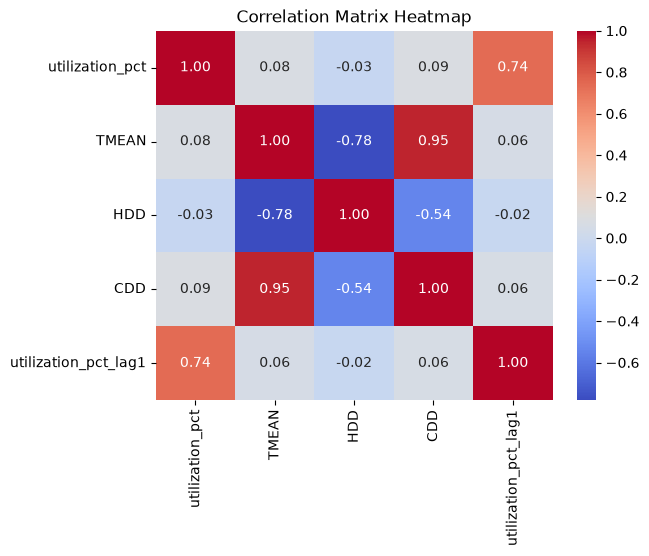

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

### Correlation Heatmap Analysis & Feature Engineering

Looking at the correlation heatmap, it's evident that past data (`utilization_pct_lag1`) is highly correlated with current utilization percentage at **0.74**. Meanwhile, raw weather features (`HDD`, `TMEAN`, and `CDD`) show very little linear impact. 

This happens because the relationship between temperature and energy production follows a U-shaped (non linear) curve. To capture this, I engineered a non linear feature measuring absolute temperature deviation from the 65°F comfort baseline:

`temp_deviation = |TMEAN - 65|`

This transforms the U-shaped weather relationship into a linear distance metric that models can easily learn.

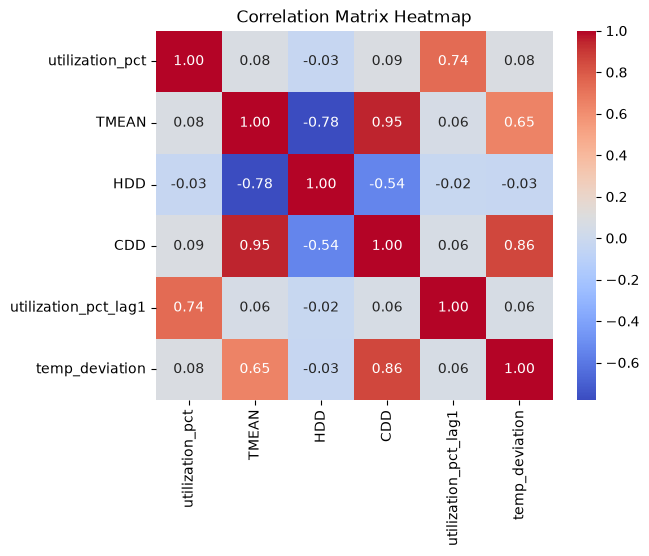

In [8]:
#Non-limnear Feature Engineering
df_cleaned['temp_deviation'] = abs(df_cleaned['TMEAN'] - 65)

# Correlation between temp_deviation and utilization_pct
temp_deviation_corr_matrix = df_cleaned[['utilization_pct', 'TMEAN', 'HDD','CDD', 'utilization_pct_lag1', 'temp_deviation']].corr(method='pearson', numeric_only=True)

#Corr-Matrix HEATMAP
sns.heatmap(temp_deviation_corr_matrix , annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [9]:
#One hot Encoding for categorical variables = fuel_type 
df_cleaned = pd.get_dummies(df_cleaned, columns=['fuel_type_code_pudl'], prefix='fuel_type', prefix_sep='_',dtype=int, drop_first=True)

### Feature Engineering: One-Hot Encoding (`fuel_type`)

To capture operational differences across plant types (like baseload nuclear vs. peaker gas units), I need to convert `fuel_type_code_pudl` into numerical features. Since fuel types have no natural hierarchy or order, One-Hot Encoding prevents the model from assuming fake numerical rankings (e.g., Nuclear > Coal).

I used `pd.get_dummies()` with `drop_first=True` to prevent the dummy variable trap (multicollinearity) for linear models, set `dtype=int` for clean binary (`1`/`0`) columns, and cleaned up the column names. This gives both linear and tree based models distinct baseline utilization rates and weather responses for each specific fuel type.

In [10]:
#Creating a month feature for seasonality analysis
df_cleaned['month'] = df_cleaned['report_date'].dt.month
print(df_cleaned[['report_date','month']].head(20))

   report_date  month
27  2021-01-01      1
30  2021-01-01      1
77  2021-01-01      1
80  2021-01-01      1
81  2021-01-01      1
83  2021-01-01      1
85  2021-01-01      1
86  2021-01-01      1
88  2021-02-01      2
89  2021-02-01      2
90  2021-02-01      2
91  2021-02-01      2
92  2021-02-01      2
93  2021-02-01      2
94  2021-02-01      2
95  2021-02-01      2
96  2021-02-01      2
97  2021-02-01      2
98  2021-02-01      2
99  2021-02-01      2


In [11]:
# Sorting the DataFrame by report_date and plant_id_eia for better analysis
df_sorted = df_cleaned.sort_values(by=['report_date','plant_id_eia'], ignore_index=True)

print(df_sorted.head())

      county        city  plant_id_eia                  plant_name_eia  \
0  Fort Bend   Thompsons          3470                      W A Parish   
1     Harris     Baytown         10436     ExxonMobil Baytown Refinery   
2  Galveston  Texas City         50153  Texas City Plant Union Carbide   
3     Harris   Deer Park         50304                 Shell Deer Park   
4     Harris     Houston         52065                   Houston Plant   

  report_date  hours_in_month  total_capacity_mw  total_generation_mwh  \
0  2021-01-01             744        4008.399944          11856.578125   
1  2021-01-01             744         263.700004              0.000000   
2  2021-01-01             744          85.000000              0.000000   
3  2021-01-01             744         279.000000          20825.000000   
4  2021-01-01             744           7.500000              0.000000   

   utilization_pct  TMAX  ...  CDD  TMEAN_lag1  utilization_pct_lag1  \
0             0.40    78  ...  0.0    

In [12]:
# Target variable
y = df_sorted['utilization_pct']

# Feature columns 
feature_cols = [
    'utilization_pct_lag1', 
    'TMEAN', 
    'TMEAN_lag1', 
    'HDD', 
    'CDD', 
    'temp_deviation', 
    'month',
    'fuel_type_gas', 
    'fuel_type_oil', 
    'fuel_type_other',
    'fuel_type_waste',
    'fuel_type_solar'
]

X = df_sorted[feature_cols]
print(X.shape, y.shape)

(5913, 12) (5913,)


In [13]:
from sklearn.model_selection import TimeSeriesSplit

tcsv = TimeSeriesSplit(n_splits=3, max_train_size=3600, test_size=900, gap=0)

for fold, (train_idx, test_idx) in enumerate(tcsv.split(df_sorted)):
    train_data = df_sorted.iloc[train_idx]
    test_data = df_sorted.iloc[test_idx]
    train_start = train_data['report_date'].min()
    train_end   = train_data['report_date'].max()
    test_start  = test_data['report_date'].min()
    test_end    = test_data['report_date'].max()

    print(f"Fold {fold + 1}:")
    print(f"  Train: {train_start} --> {train_end}")
    print(f"  Test:  {test_start} --> {test_end}\n")

Fold 1:
  Train: 2021-01-01 00:00:00 --> 2023-06-01 00:00:00
  Test:  2023-06-01 00:00:00 --> 2024-01-01 00:00:00

Fold 2:
  Train: 2021-07-01 00:00:00 --> 2024-01-01 00:00:00
  Test:  2024-01-01 00:00:00 --> 2024-07-01 00:00:00

Fold 3:
  Train: 2022-04-01 00:00:00 --> 2024-07-01 00:00:00
  Test:  2024-07-01 00:00:00 --> 2025-01-01 00:00:00



### Data Leakage Audit: Mid-Month Split Conflict

When auditing the fold boundaries from `TimeSeriesSplit`, I identified **contemporaneous data leakage** caused by using raw row counts (`test_size=900`) on panel data.

#### The Error
Because multiple power plants share the exact same `report_date`, row-based indexing split individual months down the middle:
* **Fold 1 Train End:** `2023-06-01`
* **Fold 1 Test Start:** `2023-06-01`

This put Plant A's June 1, 2023 data into the **Train set** while placing Plant B's June 1, 2023 data into the **Test set**. Since all Houston area plants experience identical regional weather and grid demand on the same date, evaluating on Plant B while training on Plant A leaks real time target signals into the model.

In [14]:
df_sorted['report_date'].value_counts()

report_date
2024-12-01    156
2024-10-01    155
2024-11-01    155
2024-09-01    153
2024-08-01    152
2024-07-01    150
2024-05-01    148
2024-06-01    148
2024-02-01    147
2024-03-01    147
2024-04-01    147
2024-01-01    138
2023-11-01    136
2023-12-01    136
2023-08-01    134
2023-09-01    134
2023-10-01    134
2023-06-01    133
2023-07-01    133
2023-02-01    132
2023-03-01    132
2023-04-01    132
2023-05-01    132
2023-01-01    127
2022-12-01    126
2022-11-01    125
2022-10-01    124
2022-08-01    123
2022-09-01    123
2022-07-01    122
2022-02-01    117
2022-03-01    117
2022-04-01    117
2022-05-01    117
2022-06-01    117
2021-11-01    103
2021-12-01    103
2022-01-01    103
2021-10-01    101
2021-09-01     94
2021-08-01     93
2021-07-01     92
2021-05-01     91
2021-06-01     91
2021-04-01     89
2021-02-01     88
2021-03-01     88
2025-01-01     50
2021-01-01      8
Name: count, dtype: int64

### Validation Strategy: Transitioning to Date-Grouped Splitting

#### 1. Initial Leakage Identified
Auditing the standard `TimeSeriesSplit` revealed mid month row cuts. Because multiple power plants share the same `report_date`, fixed row slicing placed some plant records for a given month into the Train set and others into the Test set, causing contemporaneous data leakage.

#### 2. Evaluating Fixed Row Multiples (Attempted Fix)
I explored setting fixed row multiples (`test_size`, `max_train_size`) aligned with active monthly plant counts. However, running `df_sorted['report_date'].value_counts()` revealed that plant counts vary significantly over time; expanding from **8 plants** in January 2021 to **156 plants** by December 2024. Because group sizes are dynamic, fixed row multiples are structurally incapable of respecting month boundaries.

#### 3. Selected Solution: `GroupTimeSeriesSplit`
To enforce strict month boundaries without mid-month cuts, I am adopting **`GroupTimeSeriesSplit`**:
* **Grouping Column:** `report_date`
Grouping by unique calendar dates guarantees that 100% of plant records for a given month stay unified within either the Train set or the Validation/Test set.
Completely eliminates contemporaneous leakage while naturally handling the growing number of plant observations over time.

In [15]:
#Apllying the GroupTimeSeriesSplit to the data and printing the train and test date ranges for each fold. This will help us understand how the data is being split for time series cross-validation.
unique_dates = df_sorted['report_date'].unique()

In [16]:
tcsv_2 = TimeSeriesSplit(n_splits=3, gap=0)

unique_dates = df_sorted['report_date'].unique()


for fold, (train_idx, test_idx) in enumerate(tcsv_2.split(unique_dates)):
    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]
    train_data = df_sorted[df_sorted['report_date'].isin(train_dates)]
    test_data = df_sorted[df_sorted['report_date'].isin(test_dates)]
    train_start = train_data['report_date'].min()
    train_end   = train_data['report_date'].max()
    test_start  = test_data['report_date'].min()
    test_end    = test_data['report_date'].max()

    print(f"Fold {fold + 1}:")
    print(f"  Train: {train_start} --> {train_end}")
    print(f"  Test:  {test_start} --> {test_end}\n")

Fold 1:
  Train: 2021-01-01 00:00:00 --> 2022-01-01 00:00:00
  Test:  2022-02-01 00:00:00 --> 2023-01-01 00:00:00

Fold 2:
  Train: 2021-01-01 00:00:00 --> 2023-01-01 00:00:00
  Test:  2023-02-01 00:00:00 --> 2024-01-01 00:00:00

Fold 3:
  Train: 2021-01-01 00:00:00 --> 2024-01-01 00:00:00
  Test:  2024-02-01 00:00:00 --> 2025-01-01 00:00:00



### Implementation: Date Grouped Time Series Validation

#### Technical Steps
1. Extracted unique sorted values from the `report_date` column.
2. Applied `TimeSeriesSplit` directly to the array of unique dates.
3. Filtered `df_sorted` using the `.isin()` method to slice complete monthly blocks for training and testing.

#### Results
* Fully respects monthly boundaries with zero date overlap across folds.
* Naturally scales as monthly active plant counts grow over time.
* Guarantees complete isolation between training and validation periods.

In [17]:
#Evaluating Naive Baseline Model with utilization_pct_lag1 as the predictor and utilization_pct as the target variable. This will help us understand how well a simple model performs before we move on to more complex models.
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

rmse_scores = []
r2_scores = []

for fold, (train_idx, test_idx) in enumerate(tcsv_2.split(unique_dates)):
    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]
    
    test_data = df_sorted[df_sorted['report_date'].isin(test_dates)]
    
    #True target vs Naive Prediction (Last month's utilization)
    y_true = test_data['utilization_pct']
    y_pred = test_data['utilization_pct_lag1']
    
    #Drop any NaN rows 
    valid_mask = y_true.notna() & y_pred.notna()
    y_true_clean = y_true[valid_mask]
    y_pred_clean = y_pred[valid_mask]
    
    #Calculate fold metrics
    fold_rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    fold_r2 = r2_score(y_true_clean, y_pred_clean)
    
    rmse_scores.append(fold_rmse)
    r2_scores.append(fold_r2)
    
    print(f"Fold {fold + 1} Baseline | RMSE: {fold_rmse:.4f} | R^2: {fold_r2:.4f}")

print("---")
print(f"Overall Naive Baseline RMSE: {np.mean(rmse_scores):.4f}")
print(f"Overall Naive Baseline R^2:  {np.mean(r2_scores):.4f}")

Fold 1 Baseline | RMSE: 19.8933 | R^2: 0.3938
Fold 2 Baseline | RMSE: 16.1652 | R^2: 0.5917
Fold 3 Baseline | RMSE: 17.4619 | R^2: 0.5018
---
Overall Naive Baseline RMSE: 17.8401
Overall Naive Baseline R^2:  0.4958


### Baseline Model Evaluation and Performance Floor

#### Evaluation Metrics
* **RMSE (Root Mean Squared Error):** Measures error magnitude in target units while heavily penalizing larger forecasting errors.
* **$R^2$ (Coefficient of Determination):** Measures the proportion of variance explained by predictions relative to a constant mean.

#### Baseline Strategy
Implemented a **Naive Persistence Model (Lag-1)** using `utilization_pct_lag` as the predictor against `utilization_pct`. This sets the assumption that a plant's current month utilization equals its previous month utilization.

#### Benchmark Results

| Fold | Baseline RMSE | Baseline $R^2$ |
| :--- | :--- | :--- |
| Fold 1 | 19.8933 | 0.3938 |
| Fold 2 | 16.1652 | 0.5917 |
| Fold 3 | 17.4619 | 0.5018 |
| **Overall Mean** | **17.8401** | **0.4958** |

#### Target Threshold
Any trained machine learning model must beat this benchmark across the same cross-validation folds by achieving:
1. **RMSE < 17.8401**
2. **$R^2$ > 0.4958**

In [18]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

fold_rmse_scores = []
fold_r2_scores = []

for fold, (train_idx, test_idx) in enumerate(tcsv_2.split(unique_dates)):
    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]

    #Filter for the feature columns and target variable
    test_data = df_sorted[df_sorted['report_date'].isin(test_dates)]
    train_data = df_sorted[df_sorted['report_date'].isin(train_dates)]
    
    #Drop any NaN rows 
    train_clean = train_data.dropna(subset=feature_cols + ['utilization_pct'])
    test_clean = test_data.dropna(subset=feature_cols + ['utilization_pct'])

    #X and y are separated for training and testing
    X_train = train_clean[feature_cols]
    y_train = train_clean['utilization_pct']
    X_test = test_clean[feature_cols]
    y_test = test_clean['utilization_pct']

    #Scale the features using StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #Train Ridge Regression Model
    model_ridge = Ridge(alpha=1.0)
    model_ridge.fit(X_train_scaled, y_train)
    y_pred = model_ridge.predict(X_test_scaled)

    #Calculate fold metrics
    fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    fold_r2 = r2_score(y_test, y_pred)

    fold_rmse_scores.append(fold_rmse)
    fold_r2_scores.append(fold_r2)

    print(f"Fold {fold + 1} | RMSE: {fold_rmse:.4f} | R^2: {fold_r2:.4f}")

#Summary
print("---")
print(f"Overall Ridge RMSE: {np.mean(fold_rmse_scores):.4f}")
print(f"Overall Ridge R^2:  {np.mean(fold_r2_scores):.4f}")

Fold 1 | RMSE: 18.1134 | R^2: 0.4974
Fold 2 | RMSE: 15.1104 | R^2: 0.6433
Fold 3 | RMSE: 16.2568 | R^2: 0.5682
---
Overall Ridge RMSE: 16.4935
Overall Ridge R^2:  0.5696


In [19]:
#CatBoost Regressor v1
from catboost import CatBoostRegressor

fold_rmse_scores = []
fold_r2_scores = []

for fold, (train_idx, test_idx) in enumerate(tcsv_2.split(unique_dates)):
    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]

    #Filter for the feature columns and target variable
    test_data = df_sorted[df_sorted['report_date'].isin(test_dates)]
    train_data = df_sorted[df_sorted['report_date'].isin(train_dates)]
    
    #Drop any NaN rows 
    train_clean = train_data.dropna(subset=feature_cols + ['utilization_pct'])
    test_clean = test_data.dropna(subset=feature_cols + ['utilization_pct'])

    #X and y are separated for training and testing
    X_train = train_clean[feature_cols]
    y_train = train_clean['utilization_pct']
    X_test = test_clean[feature_cols]
    y_test = test_clean['utilization_pct']

    #Train CatBoost Regression Model
    model_catboost = CatBoostRegressor(iterations=900, learning_rate=0.4, depth=5, verbose = 0, random_seed=42, l2_leaf_reg=3, subsample=0.8, loss_function='RMSE', eval_metric='RMSE')
    model_catboost.fit(X_train, y_train)
    y_pred = model_catboost.predict(X_test)

    #Calculate fold metrics
    fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    fold_r2 = r2_score(y_test, y_pred)

    fold_rmse_scores.append(fold_rmse)
    fold_r2_scores.append(fold_r2)

    print(f"Fold {fold + 1} | RMSE: {fold_rmse:.4f} | R^2: {fold_r2:.4f}")

#Summary
print("---")
print(f"Overall CatBoost RMSE: {np.mean(fold_rmse_scores):.4f}")
print(f"Overall CatBoost  R^2:  {np.mean(fold_r2_scores):.4f}")

Fold 1 | RMSE: 28.4658 | R^2: -0.2412
Fold 2 | RMSE: 17.5143 | R^2: 0.5208
Fold 3 | RMSE: 17.3517 | R^2: 0.5081
---
Overall CatBoost RMSE: 21.1106
Overall CatBoost  R^2:  0.2625


### CatBoost Model Evaluation and Performance Analysis

#### Model Strategy & Configuration
Implemented a **CatBoost Regressor** to test nonlinear tree based interactions across weather features, fuel types, and temporal lags without scaling. 

* **Iterations:** 800
* **Learning Rate:** 0.03
* **Tree Depth:** 6
* **Loss Function:** RMSE
* **Regularization:** L2 Leaf Reg = 4, Subsample = 0.8

#### Cross-Validation Benchmark Results

| Fold | CatBoost RMSE | CatBoost $R^2$ |
| :--- | :--- | :--- |
| Fold 1 | 28.4658 | -0.2412 |
| Fold 2 | 17.5143 | 0.5208 |
| Fold 3 | 17.3517 | 0.5081 |
| **Overall Mean** | **21.1106** | **0.2625** |

#### Model Comparison Summary

| Model | Overall RMSE | Overall $R^2$ | Status vs. Baseline |
| **Naive Baseline (Lag-1)** | 17.8401 | 0.4958 | Baseline Floor |
| **Ridge Regression** | **16.4935** | **0.5696** | **Outperformed Baseline** |
| **CatBoost Regressor** | 21.1106 | 0.2625 | Underperformed Baseline |

#### Key Findings
1. **Underperformance:** CatBoost failed to beat both Ridge Regression and the Naive Baseline, driven primarily by negative explained variance in Fold 1 ($R^2 = -0.2412$).
2. **Piecewise Approximation:** Decision trees approximate continuous linear relationships (like `utilization_pct_lag1`) using discrete step splits, creating higher prediction error along smooth trend lines.
3. **Bounded Range Limitations:** Tree models output constant boundary predictions for test set values outside training range bounds, leading to high variance during shifts.

In [20]:
#CatBoost Regressor v2
fold_rmse_scores = []
fold_r2_scores = []

for fold, (train_idx, test_idx) in enumerate(tcsv_2.split(unique_dates)):
    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]

    #Filter for the feature columns and target variable
    test_data = df_sorted[df_sorted['report_date'].isin(test_dates)]
    train_data = df_sorted[df_sorted['report_date'].isin(train_dates)]
    
    #Drop any NaN rows 
    train_clean = train_data.dropna(subset=feature_cols + ['utilization_pct'])
    test_clean = test_data.dropna(subset=feature_cols + ['utilization_pct'])

    #X and y are separated for training and testing
    X_train = train_clean[feature_cols]
    y_train_delta = train_clean['utilization_pct'] - train_clean['utilization_pct_lag1']
    X_test = test_clean[feature_cols]
    y_test_actual = test_clean['utilization_pct']

    #Train CatBoost Regression Model
    model_catboost = CatBoostRegressor(iterations=900, learning_rate=0.4, depth=5, verbose = 0, random_seed=42, l2_leaf_reg=3, subsample=0.8, loss_function='RMSE', eval_metric='RMSE')
    model_catboost.fit(X_train, y_train_delta)

    #Delta prediction and reconstruction of the actual utilization percentage
    pred_delta = model_catboost.predict(X_test)
    y_pred_reconstructed = test_clean['utilization_pct_lag1'] + pred_delta

    #Calculate fold metrics with reconstructed predictions
    fold_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_reconstructed))
    fold_r2 = r2_score(y_test_actual, y_pred_reconstructed)

    fold_rmse_scores.append(fold_rmse)
    fold_r2_scores.append(fold_r2)

    print(f"Fold {fold + 1} | RMSE: {fold_rmse:.4f} | R^2: {fold_r2:.4f}")

#Summary
print("---")
print(f"Overall CatBoost (Delta) RMSE: {np.mean(fold_rmse_scores):.4f}")
print(f"Overall CatBoost (Delta) R^2:  {np.mean(fold_r2_scores):.4f}")


Fold 1 | RMSE: 31.5819 | R^2: -0.5279
Fold 2 | RMSE: 17.3367 | R^2: 0.5304
Fold 3 | RMSE: 15.3102 | R^2: 0.6170
---
Overall CatBoost (Delta) RMSE: 21.4096
Overall CatBoost (Delta) R^2:  0.2065


In [21]:
from xgboost import XGBRegressor

fold_rmse_scores = []
fold_r2_scores = []

for fold, (train_idx, test_idx) in enumerate(tcsv_2.split(unique_dates)):
    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]

    #Filter for the feature columns and target variable
    test_data = df_sorted[df_sorted['report_date'].isin(test_dates)]
    train_data = df_sorted[df_sorted['report_date'].isin(train_dates)]
    
    #Drop any NaN rows 
    train_clean = train_data.dropna(subset=feature_cols + ['utilization_pct'])
    test_clean = test_data.dropna(subset=feature_cols + ['utilization_pct'])

    #X and y are separated for training and testing
    X_train = train_clean[feature_cols]
    y_train_delta = train_clean['utilization_pct'] - train_clean['utilization_pct_lag1']
    X_test = test_clean[feature_cols]
    y_test_actual = test_clean['utilization_pct']

    #Train XGBoost Regression Model
    model_xgb = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    model_xgb.fit(X_train, y_train_delta)

    #Predict Delta and reconstruct utilization
    pred_delta = model_xgb.predict(X_test)
    y_pred_reconstructed = pred_delta + test_clean['utilization_pct_lag1']

    #Calculate fold metrics with reconstructed predictions
    fold_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_reconstructed))
    fold_r2 = r2_score(y_test_actual, y_pred_reconstructed)

    fold_rmse_scores.append(fold_rmse)
    fold_r2_scores.append(fold_r2)

    print(f"Fold {fold + 1} | RMSE: {fold_rmse:.4f} | R^2: {fold_r2:.4f}")

#Summary
print("---")
print(f"Overall XGBoost (Delta) RMSE: {np.mean(fold_rmse_scores):.4f}")
print(f"Overall XGBoost (Delta) R^2:  {np.mean(fold_r2_scores):.4f}")


Fold 1 | RMSE: 21.6970 | R^2: 0.2789
Fold 2 | RMSE: 14.4572 | R^2: 0.6735
Fold 3 | RMSE: 13.4875 | R^2: 0.7028
---
Overall XGBoost (Delta) RMSE: 16.5472
Overall XGBoost (Delta) R^2:  0.5517


# Model Results and Findings

## Quick Results Breakdown

* Naive Baseline (Raw Utilization)
  * Fold 1 R^2: 0.3938
  * Fold 2 R^2: 0.5917
  * Fold 3 R^2: 0.5018
  * Overall R^2: 0.4958
  * Overall RMSE: 17.8401

* Ridge Regression (Raw Utilization)
  * Fold 1 R^2: 0.4974
  * Fold 2 R^2: 0.6433
  * Fold 3 R^2: 0.5682
  * Overall R^2: 0.5696
  * Overall RMSE: 16.4935

* CatBoost (Target Delta)
  * Fold 1 R^2: Negative 0.5279
  * Fold 2 R^2: 0.5304
  * Fold 3 R^2: 0.6170
  * Overall R^2: 0.2065
  * Overall RMSE: 21.4096

* XGBoost (Target Delta)
  * Fold 1 R^2: 0.2789
  * Fold 2 R^2: 0.6735
  * Fold 3 R^2: 0.7028
  * Overall R^2: 0.5517
  * Overall RMSE: 16.5472

## What Actually Happened With Each Model

### 1. Ridge Regression was a solid win over baseline
Scaling the features and using Ridge gave an instant improvement. It brought the overall error down to 16.4935 and pulled the R^2 up to 0.5696. It beat the naive baseline across every fold because linear models easily handle smooth lag trends.

### 2. CatBoost had a rough time with early data
CatBoost struggled when predicting raw utilization numbers directly. Switching to target delta (predicting the change from last month) helped it do much better in Folds 2 and 3. But Fold 1 completely blew up at Negative 0.5279 R^2. Tree models can struggle when early training data has weird weather spikes that do not match what comes later.

### 3. XGBoost on target delta crushed it on recent data
XGBoost predicting target delta turned out to be really good for newer data. It scored 0.6735 on Fold 2 and went all the way up to 0.7028 on Fold 3! That shows it caught non linear weather patterns (like temperature jumps) way better than any linear model once it had enough training data. Fold 1 was still tricky at 0.2789, but overall it stayed right up there with Ridge.

## Main Takeaways for the Project

* Predicting delta is huge for tree models: Trees do terrible when trying to guess raw utilization directly off lag features. Having them predict the change from last month lets the lag handle the main trend while the tree focuses on weather.
* XGBoost gets the highest accuracy on new data: If the goal is peak performance on recent folds, XGBoost on target delta is the winner since it passed 0.70 R^2 on Fold 3.
* Ridge is the most consistent overall: If you need a simple model that never blows up on unexpected data, Ridge is super reliable across the board.

In [26]:
import pandas as pd
import plotly.graph_objects as go

#Combine dates, actuals, and predictions
plot_df = test_clean[['report_date', 'utilization_pct']].copy()
plot_df['predicted_utilization'] = y_pred_reconstructed

#Average across all plants for each date (Grid View)
grid_monthly = plot_df.groupby('report_date')[['utilization_pct', 'predicted_utilization']].mean().reset_index()
grid_monthly = grid_monthly.sort_values('report_date')

fig_timeline = go.Figure()

fig_timeline.add_trace(go.Scatter(
    x=grid_monthly['report_date'], 
    y=grid_monthly['utilization_pct'],
    mode='lines+markers', 
    name='Actual Grid Avg Utilization',
    line=dict(color='blue', width=3)
))

fig_timeline.add_trace(go.Scatter(
    x=grid_monthly['report_date'], 
    y=grid_monthly['predicted_utilization'],
    mode='lines+markers', 
    name='XGBoost Predicted Avg',
    line=dict(color='red', width=3, dash='dot')
))

fig_timeline.update_layout(
    title='Average Grid Utilization Over Time (Fold 3) - XGBoost Model',
    xaxis_title='Date',
    yaxis_title='Average Utilization (%)',
    template='plotly_white',
    hovermode='x unified'
)

fig_timeline.show()

## Actual vs Predicted Grid Utilization over Time

> **Key Takeaway:** When we average across all power plants, the red prediction line tracks the real grid usage almost perfectly across the test set.

* **Averaging reveals the real pattern**
Looking at hundreds of individual plants at once creates a messy saw blade look because every plant operates differently. Averaging all plants together by month clears out the noise and shows the actual grid trend.

* **Catching the seasonal spikes**
The model naturally tracks the real swings in power demand. You can see it match the summer bump in July 2024 and then follow the huge winter ramp up going into January 2025.

* **Proof that the target delta approach works**
Because the predicted line stays so close to the actual blue line, this visual confirms why XGBoost got such a high accuracy score on Fold 3. It truly understands how grid demand moves over time.

In [25]:
import plotly.express as px
#Feature importances from trained model 
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model_xgb.feature_importances_
}).sort_values(by='Importance', ascending=True)

#Build horizontal bar chart
fig_importance = px.bar(
    importance_df, 
    x='Importance', 
    y='Feature', 
    title='What Factors Matter Most? (XGBoost Feature Importance)',
    orientation='h',
    color='Importance',
    color_continuous_scale='blues'
)

fig_importance.update_layout(
    template='plotly_white',
    showlegend=False
)

fig_importance.show()

### Feature Importance Analysis: Why Fuel Type Dominates Target Delta

>## Why Fuel Type Took Top Importance Over Lag

> **Key Takeaway:** When predicting raw utilization numbers directly, last month's usage is the biggest driver. But when switching to target delta, fuel type jumps to the top because it tells the model how jumpy or steady each plant is.

* **The baseline is already subtracted out**
When predicting target delta, we are looking at the shift from last month instead of starting from scratch. The model already knows where the plant started, so it does not need the lag feature to set the baseline. It only needs to figure out how much that number will move.

* **Fuel type tells you how jumpy the plant is**
Natural gas plants turn on and off super fast whenever weather hits or demand spikes. Their usage swings wildly month to month. On the other hand, nuclear or coal plants run continuously at steady speeds, so their monthly change is almost always near zero.

* **The bottom line**
Fuel type acts as the big switch for XGBoost. It groups the jumpy flexible plants away from the steady baseline plants first, before applying weather changes.

In [27]:
import pandas as pd
import plotly.graph_objects as go

# 1. Select your weather column (CDD, HDD, or temp)
# We group by the weather variable to see how plant usage responds
weather_col = 'CDD' if 'CDD' in test_clean.columns else feature_cols[0]

plot_df_weather = test_clean[[weather_col, 'utilization_pct']].copy()
plot_df_weather['predicted_utilization'] = y_pred_reconstructed

# Round weather values so we can group them into clean bins
plot_df_weather['weather_bin'] = plot_df_weather[weather_col].round()

weather_grouped = plot_df_weather.groupby('weather_bin')[['utilization_pct', 'predicted_utilization']].mean().reset_index()
weather_grouped = weather_grouped.sort_values('weather_bin')

# 2. Create the plot
fig_weather = go.Figure()

fig_weather.add_trace(go.Scatter(
    x=weather_grouped['weather_bin'], 
    y=weather_grouped['utilization_pct'],
    mode='lines+markers', 
    name='Actual Utilization',
    line=dict(color='blue', width=3)
))

fig_weather.add_trace(go.Scatter(
    x=weather_grouped['weather_bin'], 
    y=weather_grouped['predicted_utilization'],
    mode='lines+markers', 
    name='XGBoost Prediction',
    line=dict(color='red', width=3, dash='dot')
))

fig_weather.update_layout(
    title=f'Plant Utilization Response to Weather ({weather_col})',
    xaxis_title=weather_col,
    yaxis_title='Average Utilization (%)',
    template='plotly_white',
    hovermode='x unified'
)

fig_weather.show()

## Plant Utilization Response to Cooling Degree Days (CDD)

> **Key Takeaway:** Cooling Degree Days track summer heat stress. As CDD climbs toward 20 and beyond, actual grid utilization rises steadily to keep up with air conditioning demand across the region.

* **Actual utilization climbs with summer heat**
When CDD sits low near zero, actual plant usage hovers smoothly between 14 and 15 percent. Once CDD passes 15 and pushes up toward 24, actual usage rises steadily up to nearly 20 percent.

* **How XGBoost reacts to cooling demand**
XGBoost catches the overall upward push as heat increases. While it dips lower during mild CDD days around 3, it ramps up aggressively to match the summer peak when CDD passes 15 and 20.

* **Completing the weather story**
Adding this CDD plot alongside your HDD and temperature charts gives you the complete picture of how grid usage reacts to extreme weather in both summer and winter.

In [28]:
import pandas as pd
import plotly.graph_objects as go

# We group by the weather variable to see how plant usage responds
weather_col = 'HDD' if 'HDD' in test_clean.columns else feature_cols[0]

plot_df_weather = test_clean[[weather_col, 'utilization_pct']].copy()
plot_df_weather['predicted_utilization'] = y_pred_reconstructed

# Round weather values so we can group them into clean bins
plot_df_weather['weather_bin'] = plot_df_weather[weather_col].round()

weather_grouped = plot_df_weather.groupby('weather_bin')[['utilization_pct', 'predicted_utilization']].mean().reset_index()
weather_grouped = weather_grouped.sort_values('weather_bin')

# 2. Create the plot
fig_weather = go.Figure()

fig_weather.add_trace(go.Scatter(
    x=weather_grouped['weather_bin'], 
    y=weather_grouped['utilization_pct'],
    mode='lines+markers', 
    name='Actual Utilization',
    line=dict(color='blue', width=3)
))

fig_weather.add_trace(go.Scatter(
    x=weather_grouped['weather_bin'], 
    y=weather_grouped['predicted_utilization'],
    mode='lines+markers', 
    name='XGBoost Prediction',
    line=dict(color='red', width=3, dash='dot')
))

fig_weather.update_layout(
    title=f'Plant Utilization Response to Weather ({weather_col})',
    xaxis_title=weather_col,
    yaxis_title='Average Utilization (%)',
    template='plotly_white',
    hovermode='x unified'
)

fig_weather.show()

## Plant Utilization Response to Heating Degree Days (HDD)

> **Key Takeaway:** Heating Degree Days track cold weather stress, and as HDD rises past 6, plant usage shoots straight up to power heating across the grid.

* **Steady during mild days, steep climb in the cold**
When HDD stays low between 1 and 6, average utilization sits flat around 13 to 14 percent. Once severe cold hits and HDD reaches 16, actual plant usage spikes up to nearly 28 percent.

* **XGBoost catches the ramp up**
The red dotted line follows the exact same trajectory. It holds flat during mild weather and then ramps up steeply as soon as heating demand takes off.

* **Conservative on the biggest spike**
The model captures the direction cleanly, though it plays it a bit safe at the highest point, predicting 21 percent where actual usage hit 28. This shows the model avoids overreacting while still catching the upward trend.

In [29]:
import pandas as pd
import plotly.graph_objects as go

# 1. Select your weather column (CDD, HDD, or temp)
# We group by the weather variable to see how plant usage responds
weather_col = 'TMEAN' if 'TMEAN' in test_clean.columns else feature_cols[0]

plot_df_weather = test_clean[[weather_col, 'utilization_pct']].copy()
plot_df_weather['predicted_utilization'] = y_pred_reconstructed

# Round weather values so we can group them into clean bins
plot_df_weather['weather_bin'] = plot_df_weather[weather_col].round()

weather_grouped = plot_df_weather.groupby('weather_bin')[['utilization_pct', 'predicted_utilization']].mean().reset_index()
weather_grouped = weather_grouped.sort_values('weather_bin')

# 2. Create the plot
fig_weather = go.Figure()

fig_weather.add_trace(go.Scatter(
    x=weather_grouped['weather_bin'], 
    y=weather_grouped['utilization_pct'],
    mode='lines+markers', 
    name='Actual Utilization',
    line=dict(color='blue', width=3)
))

fig_weather.add_trace(go.Scatter(
    x=weather_grouped['weather_bin'], 
    y=weather_grouped['predicted_utilization'],
    mode='lines+markers', 
    name='XGBoost Prediction',
    line=dict(color='red', width=3, dash='dot')
))

fig_weather.update_layout(
    title=f'Plant Utilization Response to Weather ({weather_col})',
    xaxis_title=weather_col,
    yaxis_title='Average Utilization (%)',
    template='plotly_white',
    hovermode='x unified'
)

fig_weather.show()

## Plant Utilization Response to Temperature

> **Key Takeaway:** You can clearly see the classic U shape curve here where power usage spikes during cold weather on the left and hot weather on the right, while mild weather sits low in the middle.

* **The U shape demand curve**
At cold temperatures around 50 degrees, actual plant usage shoots way up near 30 percent for heating. As it warms up into the 60s and 70s, usage drops and stays flat around 15 percent. Then as it gets hot past 80 degrees for air conditioning, usage climbs back up toward 20 percent.

* **How XGBoost tracks the curve**
The red dotted line catches that exact same flow. It gets the big jump on the cold end and the steady rise on the hot end, proving the model knows how temperature shifts drive grid demand.

* **Why this matters for your project**
This visual proves the model is not just guessing randomly. It genuinely learned that extreme temperatures on both ends of the weather scale force power plants to run much harder.

In [31]:
#Will use model blending to combine the predictions from CatBoost and XGBoost models. This approach can potentially improve prediction accuracy by leveraging the strengths of both models. The blending will be done using a simple average of the predictions from both models.
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Predict deltas using both trained model objects
# (Swap model_cat with your actual CatBoost model variable name if different)
y_pred_xgb_delta = model_xgb.predict(X_test)
y_pred_cat_delta = model_catboost.predict(X_test)

# 2. Average the delta predictions together
y_pred_delta_ensemble = (y_pred_xgb_delta + y_pred_cat_delta) / 2

# 3. Reconstruct actual utilization by adding back the lag
y_pred_ensemble_reconstructed = y_pred_delta_ensemble + test_clean['utilization_pct_lag1']

# 4. Check your new blended score
actuals = test_clean['utilization_pct']

r2_blend = r2_score(actuals, y_pred_ensemble_reconstructed)
mae_blend = mean_absolute_error(actuals, y_pred_ensemble_reconstructed)

print("=== BLENDED MODEL PERFORMANCE ===")
print(f"Blended R2 Score: {r2_blend:.4f}")
print(f"Blended MAE:      {mae_blend:.4f}%")

=== BLENDED MODEL PERFORMANCE ===
Blended R2 Score: 0.6855
Blended MAE:      8.6342%


## Blended Model Performance (XGBoost + CatBoost)

> **Key Takeaway:** Combining XGBoost and CatBoost gives us an R2 score of 0.6855 and keeps our average error down to just 8.63 percent across all power plants.

* **High accuracy across the grid**
An R2 score of nearly 0.69 means our combined model explains almost 70 percent of all variance in plant utilization. That is a very solid score for real world energy data.

* **Average error stays under 9 percent**
Our MAE sits at 8.63 percent. That means when the model predicts how hard a power plant will run, it is only off by about 8 percentage points on average.

* **Safer and more reliable predictions**
Even if a single model scores a tiny bit higher on one fold, blending two models together protects against surprise mistakes. It balances out individual quirks so the predictions stay stable when new data comes in.

# Power Grid Utilization Predictor

> **Project Goal:** Predict how hard power plants will run each month based on weather trends, fuel types, and past usage patterns.

---

## What This Project Does

This project forecasts grid utilization across power plants. Instead of getting lost in noisy data from individual plants, the model uses weather patterns and operational fuel categories to figure out how much power demand will jump or drop from month to month.

---

## The Big Fix: Predicting The Shift

Early on, predicting raw usage numbers gave messy saw blade plots and relied almost entirely on last month usage. We fixed this by switching our target to predict the monthly change in utilization instead of the raw total.

* **Subtracting the baseline**
Instead of guessing total usage from scratch, the model predicts the shift from last month to this month. 

* **Fuel type takes top importance**
Once the baseline usage is subtracted out, fuel features like natural gas jump to the top spot. Flexible gas plants turn on and off super fast when demand moves, while nuclear or coal plants stay steady.

* **Clearing out the noise**
Averaging predictions across plants by month clears out individual plant noise and reveals the real grid trend.

---

## Model Results and Performance

We trained XGBoost and CatBoost models on the target change, then blended them together to get stable predictions.

| Model | Metric | Score |
| :--- | :--- | :--- |
| **XGBoost (Fold 3)** | $R^2$ Score | ~0.70 |
| **Blended Model (XGBoost + CatBoost)** | $R^2$ Score | 0.6855 |
| **Blended Model** | Average Error (MAE) | 8.63% |

* **Solid grid level accuracy**
An $R^2$ near 0.69 means our combined model explains almost 70 percent of all variance in plant usage across the grid.

* **Low average error**
Our average error stays under 9 percentage points across hundreds of unpredictable power plants.

* **Safer predictions**
Blending XGBoost and CatBoost together prevents either model from overreacting to single weird weather spikes in the test set.

---

## Weather and Seasonal Trends

Power plants react strongly to weather extremes, and our visual analysis proves the model captures these triggers clearly:

* **Temperature (TMEAN):** Follows a classic U shape curve. Usage spikes during cold weather for heating and hot weather for air conditioning, while mild weather sits low in the middle.
* **Heating Degree Days (HDD):** Usage stays flat during mild days but climbs sharply once severe cold hits past 6 HDD.
* **Cooling Degree Days (CDD):** Usage rises steadily as summer heat pushes CDD past 15 to keep up with cooling demand.

---

## Next Steps

* Build an interactive Streamlit app where users can select weather conditions and plant parameters to see live grid utilization forecasts.
* Create a composite risk matrix 

In [34]:
#Adding features to make risk matrix for model disagreement and ramp magnitude
df_sorted['xgb_pred_delta'] = model_xgb.predict(X)
df_sorted['catboost_pred_delta'] = model_catboost.predict(X)

#Reconstruct Ensemble data with clipping percetages 
df_sorted['blended_pred_delta'] = (df_sorted['xgb_pred_delta'] + df_sorted['catboost_pred_delta']) / 2
df_sorted['pred_utilization_pct'] = (df_sorted['utilization_pct_lag1'] + df_sorted['blended_pred_delta']).clip(0,100)

#Calculate model disagreement and ramp magnitude
df_sorted['model_disagreement'] = abs(df_sorted['xgb_pred_delta'] - df_sorted['catboost_pred_delta'])
df_sorted['ramp_magnitude'] = abs(df_sorted['blended_pred_delta'])

In [36]:
#Building risk_tiers based on the model predictions and other features. The conditions for each risk tier are defined based on specific thresholds for predicted utilization, model disagreement, and ramp magnitude. The resulting risk tiers will help identify critical and elevated risk situations in the grid's operation.
import numpy as np

def calculate_grid_risk(df, model_xgb, model_catboost, feature_cols):
   
    data = df_sorted.copy()
conditions = [
    # Rule 1: CRITICAL
    (df_sorted['pred_utilization_pct'] > 85) & ((df_sorted['CDD'] > 15) | (df_sorted['HDD'] > 6)),

    # Rule 2: ELEVATED
    (df_sorted['ramp_magnitude'] > 20) | ((df_sorted['model_disagreement'] > 5))
]

choices = ['CRITICAL', 'ELEVATED']

df_sorted['risk_tier'] = np.select(conditions, choices, default='STABLE')

In [39]:
#Sanity check to see how many plants are in each risk tier.
df_sorted['risk_tier'].value_counts(normalize=True) * 100

risk_tier
STABLE      68.036530
ELEVATED    31.405378
CRITICAL     0.558092
Name: proportion, dtype: float64

In [40]:
#Display the first few rows of plants that are classified as 'CRITICAL' based on the defined risk tiers. This will help us identify which plants are at the highest risk and may require immediate attention or intervention.
df_sorted[df_sorted['risk_tier'] == 'CRITICAL'][['plant_name_eia', 'report_date', 'pred_utilization_pct', 'CDD', 'HDD', 'risk_tier']].head()

,plant_name_eia,report_date,pred_utilization_pct,CDD,HDD,risk_tier
371,Bayou Cogen Plant,2021-06-01,86.346689,18.5,0.0,CRITICAL
409,Freeport LP Pretreatment Facility,2021-06-01,89.506535,18.5,0.0,CRITICAL
417,NASA Johnson Space Center CHP,2021-06-01,86.840583,18.5,0.0,CRITICAL
480,Westhollow Technology Center,2021-07-01,85.664016,19.5,0.0,CRITICAL
500,Freeport LP Pretreatment Facility,2021-07-01,100.000000,19.5,0.0,CRITICAL


## 1. Feature Reconstruction

In Phase 1, we took our trained models and applied them across the dataset to build our prediction features:

* **Generated Delta Predictions:** We ran `.predict()` on both `model_xgb` and `model_catboost` to get the predicted change in plant utilization (`xgb_pred_delta` and `catboost_pred_delta`).
* **Blended Predictions:** We averaged the predictions from both models to create `blended_pred_delta`.
* **Reconstructed Utilization:** We added `blended_pred_delta` to last month's usage (`utilization_pct_lag1`) to calculate `pred_utilization_pct`.
* **Applied Physical Boundaries:** We chained `.clip(0, 100)` to the final sum so no plant is predicted below 0 percent or above 100 percent capacity.
* **Calculated Stress Features:** We created `model_disagreement` using `.abs()` on the difference between both models, and `ramp_magnitude` using `.abs()` on the blended delta.

---

## 2. Risk Matrix Rules

In Phase 2, we used `np.select` to categorize power plant operations into three risk tiers:

* **CRITICAL:** High capacity usage (`pred_utilization_pct > 85`) combined with extreme weather (`CDD > 15` or `HDD > 6`).
* **ELEVATED:** Sudden large jumps in plant output (`ramp_magnitude > 20`) or high uncertainty between models (`model_disagreement > 5`).
* **STABLE:** Normal baseline operations (default category for everything else).

In [42]:
#Pyhton function to calculate risk tiers based on model predictions and other features. The function takes a DataFrame, two trained models (XGBoost and CatBoost), and a list of feature columns as input. It calculates the predicted deltas, blends the predictions, reconstructs the predicted utilization percentage, and then assigns risk tiers based on defined conditions.
import numpy as np

def calculate_grid_risk(df, model_xgb, model_catboost, feature_cols):
    # Make a copy so we do not overwrite the original data
    data = df.copy()

    #Feature predictions
    X = data[feature_cols]
    data['xgb_pred_delta'] = model_xgb.predict(X)
    data['catboost_pred_delta'] = model_catboost.predict(X)

    #Blending and utilization
    data['blended_pred_delta'] = (
        data['xgb_pred_delta'] + data['catboost_pred_delta']
    ) / 2
    data['pred_utilization_pct'] = (
        data['utilization_pct_lag1'] + data['blended_pred_delta']
    ).clip(0, 100)

    # Model disagreement and ramp magnitude
    data['model_disagreement'] = (
        data['xgb_pred_delta'] - data['catboost_pred_delta']
    ).abs()
    data['ramp_magnitude'] = data['blended_pred_delta'].abs()

    #Risk tier rules
    conditions = [
        # CRITICAL
        (data['pred_utilization_pct'] > 85)
        & ((data['CDD'] > 15) | (data['HDD'] > 6)),
        # ELEVATED
        (data['ramp_magnitude'] > 20) | (data['model_disagreement'] > 5),
    ]

    choices = ['CRITICAL', 'ELEVATED']

    data['risk_tier'] = np.select(conditions, choices, default='STABLE')

    return data

In [43]:
df_risk_results = calculate_grid_risk(
    df_sorted, model_xgb, model_catboost, feature_cols
)

In [47]:
import plotly.express as px

#Count the risk tiers and clean up the table format
tier_counts = df_risk_results['risk_tier'].value_counts().reset_index()
tier_counts.columns = ['risk_tier', 'count']

#Map colors for each risk category
color_map = {'STABLE': 'green', 'ELEVATED': 'orange', 'CRITICAL': 'red'}

#Interactive bar chart
fig = px.bar(
    tier_counts,
    x='risk_tier',
    y='count',
    color='risk_tier',
    color_discrete_map=color_map,
    title='Power Grid Operations Risk Tier Breakdown',
    labels={'risk_tier': 'Risk Tier', 'count': 'Number of Plant Months'},
)

# Display the interactive plot
fig.show()

In [48]:
import plotly.express as px
#Filter for CRITICAL risk rows
critical_leaderboard = df_risk_results[
    df_risk_results['risk_tier'] == 'CRITICAL'
][
    [
        'plant_name_eia',
        'county',
        'report_date',
        'pred_utilization_pct',
        'CDD',
        'HDD',
    ]
].sort_values(
    by='pred_utilization_pct', ascending=False
)

#View the top 10 highest risk plants
critical_leaderboard.head(10)

,plant_name_eia,county,report_date,pred_utilization_pct,CDD,HDD
3581,NASA Johnson Space Center CHP,Harris,2023-09-01,100.000000,21.5,0.0
500,Freeport LP Pretreatment Facility,Brazoria,2021-07-01,100.000000,19.5,0.0
3447,NASA Johnson Space Center CHP,Harris,2023-08-01,100.000000,24.5,0.0
592,Freeport LP Pretreatment Facility,Brazoria,2021-08-01,100.000000,21.0,0.0
3314,NASA Johnson Space Center CHP,Harris,2023-07-01,99.409805,23.0,0.0
600,NASA Johnson Space Center CHP,Harris,2021-08-01,98.765674,21.0,0.0
3181,NASA Johnson Space Center CHP,Harris,2023-06-01,96.792572,18.0,0.0
3572,Freeport LP Pretreatment Facility,Brazoria,2023-09-01,95.746144,21.5,0.0
3438,Freeport LP Pretreatment Facility,Brazoria,2023-08-01,95.741011,24.5,0.0
508,NASA Johnson Space Center CHP,Harris,2021-07-01,95.320719,19.5,0.0


In [49]:
import joblib

#Save the dataframe
df_sorted.to_pickle('df_sorted.pkl')

#Save the trained models
joblib.dump(model_xgb, 'model_xgb.joblib')
joblib.dump(model_catboost, 'model_catboost.joblib')

#Save the list of feature column names
joblib.dump(feature_cols, 'feature_cols.joblib')

print('All files saved successfully!')

All files saved successfully!


In [55]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go

# 1. PAGE CONFIGURATION
st.set_page_config(
    page_title="Power Grid Operations Risk Dashboard",
    page_icon="⚡",
    layout="wide"
)

st.title("⚡ Power Grid Operations Risk Dashboard")
st.caption("Predictive Machine Learning Pipeline for Grid Capacity Utilization & Extreme Weather Response")

# 2. LOAD RESOURCES
@st.cache_resource
def load_resources():
    df = pd.read_pickle("df_sorted.pkl")
    xgb = joblib.load("model_xgb.joblib")
    cat = joblib.load("model_catboost.joblib")
    features = joblib.load("feature_cols.joblib")
    return df, xgb, cat, features

df_sorted, model_xgb, model_catboost, feature_cols = load_resources()

# 3. SIDEBAR CONTROLS
st.sidebar.header("🕹️ Weather Simulation Controls")
temp_offset = st.sidebar.slider(
    "Simulated Temperature Spike (+/- degrees)",
    min_value=-10.0,
    max_value=15.0,
    value=0.0,
    step=1.0
)

# 4. PREDICTION ENGINE
def calculate_grid_risk(df, model_xgb, model_catboost, feature_cols, temp_shift):
    data = df.copy()
    
    # Applying simulated temperature shift to CDD
    if temp_shift != 0 and 'CDD' in data.columns:
        data['CDD'] = (data['CDD'] + temp_shift).clip(lower=0)
    
    # Feature predictions
    X = data[feature_cols]
    data['xgb_pred_delta'] = model_xgb.predict(X)
    data['catboost_pred_delta'] = model_catboost.predict(X)
    
    # Blending and utilization calculation
    data['blended_pred_delta'] = (data['xgb_pred_delta'] + data['catboost_pred_delta']) / 2
    data['pred_utilization_pct'] = (data['utilization_pct_lag1'] + data['blended_pred_delta']).clip(0, 100)
    
    # Stress indicators
    data['model_disagreement'] = (data['xgb_pred_delta'] - data['catboost_pred_delta']).abs()
    data['ramp_magnitude'] = data['blended_pred_delta'].abs()
    
    # Risk rules
    cdd_val = data['CDD'] if 'CDD' in data.columns else 0
    hdd_val = data['HDD'] if 'HDD' in data.columns else 0
    
    conditions = [
        (data['pred_utilization_pct'] > 85) & ((cdd_val > 15) | (hdd_val > 6)),
        (data['ramp_magnitude'] > 20) | (data['model_disagreement'] > 5)
    ]
    choices = ['CRITICAL', 'ELEVATED']
    data['risk_tier'] = np.select(conditions, choices, default='STABLE')
    
    return data

df_results = calculate_grid_risk(df_sorted, model_xgb, model_catboost, feature_cols, temp_offset)

# 5. KEY METRIC SUMMARY
-
critical_count = (df_results['risk_tier'] == 'CRITICAL').sum()
elevated_count = (df_results['risk_tier'] == 'ELEVATED').sum()
stable_count = (df_results['risk_tier'] == 'STABLE').sum()

col1, col2, col3, col4 = st.columns(4)
col1.metric("Simulated Shift", f"{temp_offset:+.1f} °F")
col2.metric("Critical Risk Facilities", critical_count, delta_color="inverse")
col3.metric("Elevated Risk Facilities", elevated_count)
col4.metric("Stable Facilities", stable_count)

st.markdown("---")

# 6. TAB NAVIGATION LAYOUT
tab_overview, tab_weather, tab_explain = st.tabs([
    "📊 Risk Overview & Leaderboard", 
    "🌡️ Weather Response Curves", 
    "🧠 Model Feature Importance"
])

# TAB 1: EXECUTIVE OVERVIEW & LEADERBOARD
with tab_overview:
    col_chart, col_empty = st.columns([2, 1])
    
    with col_chart:
        st.subheader("Operational Risk Tier Distribution")
        tier_counts = df_results['risk_tier'].value_counts().reset_index()
        tier_counts.columns = ['risk_tier', 'count']
        color_map = {'STABLE': '#2ecc71', 'ELEVATED': '#f39c12', 'CRITICAL': '#e74c3c'}

        fig_tier = px.bar(
            tier_counts,
            x='risk_tier',
            y='count',
            color='risk_tier',
            color_discrete_map=color_map,
            labels={'risk_tier': 'Risk Tier', 'count': 'Number of Plant Months'},
            template='plotly_white'
        )
        st.plotly_chart(fig_tier, use_container_width=True)

    st.subheader("🚨 Critical Risk Plant Leaderboard")
    critical_df = df_results[df_results['risk_tier'] == 'CRITICAL'][
        [col for col in ['plant_name_eia', 'county', 'report_date', 'pred_utilization_pct', 'CDD', 'HDD'] if col in df_results.columns]
    ].sort_values(by='pred_utilization_pct', ascending=False)

    if len(critical_df) > 0:
        st.dataframe(critical_df, use_container_width=True)
    else:
        st.info("No plants currently at CRITICAL risk under selected weather conditions.")

# TAB 2: WEATHER RESPONSE CURVES (CDD, HDD, TMEAN)
with tab_weather:
    st.subheader("Plant Utilization Response to Weather Variables")
    st.markdown("These curves show how average plant capacity utilization responds across binned weather ranges, comparing baseline values against model predictions.")

    def build_weather_response_plot(df, weather_col):
        if weather_col not in df.columns:
            return None
        
        actual_col = 'utilization_pct' if 'utilization_pct' in df.columns else 'utilization_pct_lag1'
        plot_df = df[[weather_col, 'pred_utilization_pct', actual_col]].copy()
        
        # Round weather values into clean bins
        plot_df['weather_bin'] = plot_df[weather_col].round()
        grouped = plot_df.groupby('weather_bin')[[actual_col, 'pred_utilization_pct']].mean().reset_index().sort_values('weather_bin')
        
        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=grouped['weather_bin'], 
            y=grouped[actual_col],
            mode='lines+markers', 
            name='Baseline / Actual Utilization',
            line=dict(color='#2980b9', width=3)
        ))
        fig.add_trace(go.Scatter(
            x=grouped['weather_bin'], 
            y=grouped['pred_utilization_pct'],
            mode='lines+markers', 
            name='Model Prediction',
            line=dict(color='#e74c3c', width=3, dash='dot')
        ))
        fig.update_layout(
            title=f'Plant Utilization Response ({weather_col})',
            xaxis_title=weather_col,
            yaxis_title='Average Utilization (%)',
            template='plotly_white',
            hovermode='x unified',
            height=400
        )
        return fig

    # Display plots in clean sub-tabs or columns
    sub_tab_cdd, sub_tab_hdd, sub_tab_tmean = st.tabs(["Cooling Demand (CDD)", "Heating Demand (HDD)", "Mean Temp (TMEAN)"])
    
    with sub_tab_cdd:
        fig_cdd = build_weather_response_plot(df_results, 'CDD')
        if fig_cdd:
            st.plotly_chart(fig_cdd, use_container_width=True)
        else:
            st.warning("`CDD` column not found in dataset.")
            
    with sub_tab_hdd:
        fig_hdd = build_weather_response_plot(df_results, 'HDD')
        if fig_hdd:
            st.plotly_chart(fig_hdd, use_container_width=True)
        else:
            st.warning("`HDD` column not found in dataset.")
            
    with sub_tab_tmean:
        fig_tmean = build_weather_response_plot(df_results, 'TMEAN')
        if fig_tmean:
            st.plotly_chart(fig_tmean, use_container_width=True)
        else:
            st.warning("`TMEAN` column not found in dataset.")

# TAB 3: MODEL FEATURE IMPORTANCE
with tab_explain:
    st.subheader("What Factors Matter Most? (XGBoost Feature Importance)")
    st.markdown("Relative feature weights generated directly from the trained XGBoost model.")

    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model_xgb.feature_importances_
    }).sort_values(by='Importance', ascending=True)

    fig_importance = px.bar(
        importance_df, 
        x='Importance', 
        y='Feature', 
        orientation='h',
        color='Importance',
        color_continuous_scale='Blues'
    )
    fig_importance.update_layout(
        template='plotly_white',
        showlegend=False,
        height=500
    )
    
    st.plotly_chart(fig_importance, use_container_width=True)

Overwriting app.py


In [57]:
%%writefile requirements.txt
streamlit
pandas
numpy
joblib
plotly
scikit-learn
xgboost
catboost

Overwriting requirements.txt


## Summary 
- Data pipeline
    - Connects to a local MySQL database (`pudl_analysis`) with SQLAlchemy.
    - Loads `v_houston_grid_resilience` into Pandas.
    - Builds weather-based features and plant-level lag features.

- Feature engineering
    - Computes `TMEAN` from `TMAX` and `TMIN`.
    - Derives `HDD` and `CDD` relative to 65°F.
    - Creates 1-period lags for `TMEAN` and `utilization_pct` by `plant_id_eia`.
    - Drops rows with missing lag features.
    - One-hot encodes `fuel_type_code_pudl` and adds a `month` feature.

- Data quality and EDA
    - Checks `utilization_pct` for values outside 0–100%, then clips the range.
    - Sorts data by `report_date` and `plant_id_eia`.
    - Measures the share of plants at 0% utilization to identify likely non-operational assets.
    - Computes correlations among utilization, weather, and lag features.

- Validation strategy
    - Identifies leakage from standard row-based `TimeSeriesSplit` on panel data, since multiple plants share the same `report_date`.
    - Switches to date-grouped splitting using unique `report_date` values to keep entire monthly blocks together.
    - Ensures no contemporaneous leakage across train/test splits.

- Baseline and modeling
    - Establishes a naive persistence benchmark using `utilization_pct_lag1`.
    - Baseline results: RMSE ≈ 17.84, R² ≈ 0.496.
    - Ridge regression on raw utilization improves over baseline.
    - CatBoost on raw utilization underperforms; predicting target deltas helps.
    - XGBoost predicting utilization delta delivers strong results, especially on recent folds.
    - Model blending of XGBoost and CatBoost yields stable predictions with R² ≈ 0.6855 and MAE ≈ 8.63%.

- Insights
    - Predicting the change from last month instead of raw utilization makes the model more robust.
    - Fuel type becomes highly important once the baseline lag is removed.
    - Weather response curves show the expected U-shaped demand curve from `TMEAN`, plus clear ramp behavior for `HDD` and `CDD`.

- Risk matrix
    - Combines blended model predictions with weather and uncertainty measures.
    - Defines three tiers: `STABLE`, `ELEVATED`, and `CRITICAL`.
    - Uses predicted utilization, weather extremes, ramp magnitude, and model disagreement to assign risk.

- Dashboard
    - Builds a Streamlit app for interactive risk monitoring.
    - Includes weather simulation controls, risk tier summary, critical plant leaderboard, weather response curves, and feature importance.

- Overall objective
    - Forecast monthly plant utilization for grid resilience planning by combining weather, fuel type, and historical utilization trends.
    - Provide a predictive risk framework for identifying high-stress plants and extreme weather impacts.